In [1]:
import pandas as pd

file_path = 'benign_vs_defacement_urls.csv'

try:
    # Use Python engine and ISO-8859-1 encoding for better error handling
    df = pd.read_csv(file_path, encoding='ISO-8859-1', engine='python', on_bad_lines='skip')

    print("----- HEAD (first 5 rows) -----")
    print(df.head())

    print("\n----- TAIL (last 5 rows) -----")
    print(df.tail())  

    print("\n----- Class Distribution -----")
    print(df['type'].value_counts())

except Exception as e:
    print(f"❌ An error occurred: {e}")

----- HEAD (first 5 rows) -----
                                                 url    type
0                mp3raid.com/music/krizz_kaliko.html  benign
1                    bopsecrets.org/rexroth/cr/1.htm  benign
2  http://buzzfil.net/m/show-art/ils-etaient-loin...  benign
3      espn.go.com/nba/player/_/id/3457/brandon-rush  benign
4     yourbittorrent.com/?q=anthony-hamilton-soulife  benign

----- TAIL (last 5 rows) -----
                                                      url        type
524613  http://blueanchor.nl/dintelmarkt/page/show_cat...  defacement
524614                http://www.hafenrocker.de/index.php  defacement
524615  http://www.kulgupuit.ee/index.php?option=com_p...  defacement
524616   http://www.nhomkinhdep.com/tu-bep-nhom-kinh.html  defacement
524617  http://www.capella.nl/nl.html?view=article&cat...  defacement

----- Class Distribution -----
type
benign        428103
defacement     96454
Name: count, dtype: int64


In [2]:
import pandas as pd
import re

# Load the data
file_path = 'benign_vs_defacement_urls.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1', engine='python', on_bad_lines='skip')

# Display initial shape
print("Original shape:", df.shape)

# 1. Remove missing or malformed URLs
df = df.dropna(subset=['url', 'type'])  # Drop rows where URL or type is NaN
df = df[df['url'].str.strip() != '']   # Drop rows with empty strings in 'url'

# 2. Encode labels: 'benign' -> 0, 'defacement' -> 1
df['label'] = df['type'].map({'benign': 0, 'defacement': 1})

# Drop any rows that failed mapping
df = df.dropna(subset=['label'])

# Convert label to integer type
df['label'] = df['label'].astype(int)

# 3. (Optional) Normalize URLs: lowercase and remove special characters
def clean_url(url):
    url = url.lower()  # convert to lowercase
    url = re.sub(r'[^a-z0-9/:.?&=_-]', '', url)  
    return url

df['url_clean'] = df['url'].apply(clean_url)

# Display results
print("Cleaned shape:", df.shape)
print(df[['url', 'url_clean', 'type', 'label']].head())


Original shape: (524618, 2)
Cleaned shape: (524549, 4)
                                                 url  \
0                mp3raid.com/music/krizz_kaliko.html   
1                    bopsecrets.org/rexroth/cr/1.htm   
2  http://buzzfil.net/m/show-art/ils-etaient-loin...   
3      espn.go.com/nba/player/_/id/3457/brandon-rush   
4     yourbittorrent.com/?q=anthony-hamilton-soulife   

                                           url_clean    type  label  
0                mp3raid.com/music/krizz_kaliko.html  benign      0  
1                    bopsecrets.org/rexroth/cr/1.htm  benign      0  
2  http://buzzfil.net/m/show-art/ils-etaient-loin...  benign      0  
3      espn.go.com/nba/player/_/id/3457/brandon-rush  benign      0  
4     yourbittorrent.com/?q=anthony-hamilton-soulife  benign      0  


In [3]:
from collections import Counter
import pandas as pd
import re

# Example stop tokens to exclude
stop_tokens = {"www", "com", "org", "net", "html", "php", "index"}

def tokenize_urls(urls):
    all_tokens = []
    for url in urls:
        tokens = re.split(r'\W+', str(url).lower())
        filtered = [
            t for t in tokens
            if 3 <= len(t) <= 5 and not t.isdigit() and t not in stop_tokens
        ]
        all_tokens.extend(filtered)
    return all_tokens

# Assuming df is your DataFrame with 'url_clean' and 'label' columns
all_tokens = tokenize_urls(df['url_clean'])
token_counts = Counter(all_tokens)
top_2000_tokens = [token for token, _ in token_counts.most_common(2000)]

benign_counts = Counter()
deface_counts = Counter()

for url in df[df['label'] == 0]['url_clean']:
    tokens = set(re.split(r'\W+', str(url).lower()))
    for token in top_2000_tokens:
        if token in tokens and token not in stop_tokens and not token.isdigit() and 3 <= len(token) <= 5:
            benign_counts[token] += 1

for url in df[df['label'] == 1]['url_clean']:
    tokens = set(re.split(r'\W+', str(url).lower()))
    for token in top_2000_tokens:
        if token in tokens and token not in stop_tokens and not token.isdigit() and 3 <= len(token) <= 5:
            deface_counts[token] += 1

token_data = []
for token in top_2000_tokens:
    benign_freq = benign_counts[token]
    deface_freq = deface_counts[token]
    # Add +1 smoothing to avoid division by zero
    ratio = (deface_freq + 1) / (benign_freq + 1)
    token_data.append((token, benign_freq, deface_freq, ratio))

df_tokens = pd.DataFrame(token_data, columns=['Token', 'Benign_Freq', 'Deface_Freq', 'Deface_to_Benign_Ratio'])
df_tokens_sorted = df_tokens.sort_values(by='Deface_to_Benign_Ratio', ascending=False).reset_index(drop=True)

#print(df_tokens_sorted.head(200))
print(df_tokens_sorted)

all_tokens = top_2000_tokens
print(f"Total unique tokens to use as features: {len(all_tokens)}")


      Token  Benign_Freq  Deface_Freq  Deface_to_Benign_Ratio
0     zibae            0          188              189.000000
1      tmpl           69        11179              159.714286
2     hirek            0          121              122.000000
3      fuer            1          240              120.500000
4     siamo            0          109              110.000000
...     ...          ...          ...                     ...
1995  https         2264            0                0.000442
1996  shtml         2278            0                0.000439
1997    cfm         2809            0                0.000356
1998    ref         4256            0                0.000235
1999    cgi         6130            0                0.000163

[2000 rows x 4 columns]
Total unique tokens to use as features: 2000


In [4]:
import joblib
joblib.dump(all_tokens, 'all_tokens.pkl') 
import re
import gc  # added for memory cleanup

def url_to_feature_vector(url, token_list):
    tokens_in_url = set(re.split(r'\W+', url.lower()))
    return [1 if token in tokens_in_url else 0 for token in token_list]

features = []
for url in df['url_clean'].fillna(""):
    features.append(url_to_feature_vector(url, all_tokens))

features_df = pd.DataFrame(features, columns=all_tokens)
features_df['label'] = df['label'].values
print(features_df.shape)

selected_cols = ['https', 'shtml', 'shtml', 'tmpl', 'ref', 'mens', 'brown']
mask = features_df[selected_cols].sum(axis=1) > 0

# Filter rows and create a copy to avoid SettingWithCopyWarning
filtered_df = features_df[mask].copy()

# Align the filtered rows with original df to add 'url_clean' correctly
filtered_df['url_clean'] = df['url_clean'].iloc[filtered_df.index.values].values


# Take 5 random samples from each class (label 0 and label 1)
sample_0 = filtered_df[filtered_df['label'] == 0].sample(5, random_state=42)
sample_1 = filtered_df[filtered_df['label'] == 1].sample(5, random_state=42)

# Combine the samples
balanced_sample = pd.concat([sample_0, sample_1])

# Print only relevant columns without index
print(balanced_sample[['url_clean'] + selected_cols + ['label']].to_string(index=False))

# === Save the FULL features_df (all rows) to CSV ===
features_df.to_csv('full_features_data.csv', index=False)

# Clear features_df from memory and run garbage collector
del features_df
gc.collect()


(524549, 2000)
                                                                                                                                                                                                                                    url_clean  https  shtml  shtml  tmpl  ref  mens  brown  label
                                                                                                                                                                                                         mog.com/artists/mn24579/norman-brown      0      0      0     0    0     0      1      0
                                                                                                                                            esxcc.com/js/index.htm?us.battle.net/login/en/?ref=kipbejdus.battle.net/d3/en/index&ampapp=com-d3      0      0      0     0    1     0      0      0
                                                                                                                   

0

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy import sparse

# Load the dataset from CSV with reduced memory usage
df = pd.read_csv('full_features_data.csv', dtype='int8')

print(f"Memory usage of DataFrame: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# Drop 'url_clean' if exists, else ignore
df = df.drop(columns=['url_clean'], errors='ignore')

# Separate features and label
X = df.drop(columns=['label'])
y = df['label'].astype('int8')

# Optionally convert to sparse matrix to save memory
X_sparse = sparse.csr_matrix(X.values)

# Split data into train and test sets (using sparse matrix)
X_train, X_test, y_train, y_test = train_test_split(
    X_sparse, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain label distribution:\n", y_train.value_counts(normalize=True))
print("\nTest label distribution:\n", y_test.value_counts(normalize=True))


Memory usage of DataFrame: 1000.50 MB
Train shape: (419639, 1999)
Test shape: (104910, 1999)

Train label distribution:
 label
0    0.816135
1    0.183865
Name: proportion, dtype: float64

Test label distribution:
 label
0    0.816138
1    0.183862
Name: proportion, dtype: float64



🔄 Training: Logistic Regression
✅ Logistic Regression - Accuracy: 0.9851, Precision: 0.9402, Recall: 0.9814, F1: 0.9603, Time: 3.83s
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     85621
           1       0.94      0.98      0.96     19289

    accuracy                           0.99    104910
   macro avg       0.97      0.98      0.98    104910
weighted avg       0.99      0.99      0.99    104910


🔄 Training: Random Forest
✅ Random Forest - Accuracy: 0.9861, Precision: 0.9415, Recall: 0.9857, F1: 0.9631, Time: 163.84s
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     85621
           1       0.94      0.99      0.96     19289

    accuracy                           0.99    104910
   macro avg       0.97      0.99      0.98    104910
weighted avg       0.99      0.99      0.99    104910


🔄 Training: Naive Bayes (Bernoulli)

c:\Users\outlo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:17:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost - Accuracy: 0.9809, Precision: 0.9187, Recall: 0.9832, F1: 0.9498, Time: 0.99s
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85621
           1       0.92      0.98      0.95     19289

    accuracy                           0.98    104910
   macro avg       0.96      0.98      0.97    104910
weighted avg       0.98      0.98      0.98    104910


🔄 Training: KNN
✅ KNN - Accuracy: 0.9784, Precision: 0.9003, Recall: 0.9924, F1: 0.9441, Time: 0.02s
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85621
           1       0.90      0.99      0.94     19289

    accuracy                           0.98    104910
   macro avg       0.95      0.98      0.97    104910
weighted avg       0.98      0.98      0.98    104910


🔄 Training: MLP Neural Net
✅ MLP Neural Net - Accuracy: 0.9868, Precision: 0.9434, Recall: 0.9874, F1:

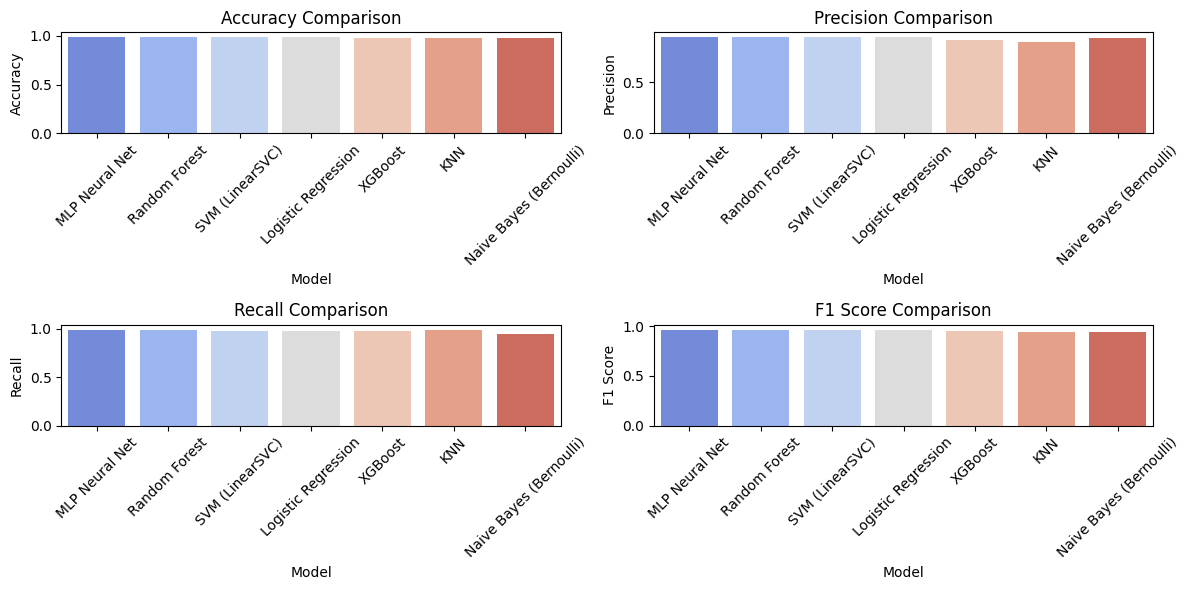

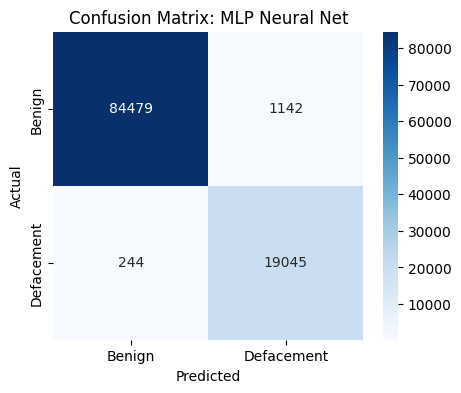


📋 Final Model Comparison:
                  Model  Accuracy  Precision   Recall  F1 Score  Train Time (s)
         MLP Neural Net  0.986789   0.943429 0.987350  0.964890      526.276162
          Random Forest  0.986112   0.941517 0.985691  0.963098      163.837454
        SVM (LinearSVC)  0.985254   0.941695 0.980507  0.960709        1.945343
    Logistic Regression  0.985092   0.940154 0.981388  0.960329        3.826801
                XGBoost  0.980898   0.918665 0.983151  0.949815        0.993420
                    KNN  0.978391   0.900292 0.992379  0.944095        0.020520
Naive Bayes (Bernoulli)  0.977619   0.930959 0.948624  0.939708        0.071772


In [6]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Assuming X_train, X_test, y_train, y_test are already prepared and are sparse matrices if needed

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_jobs=-1),
    "Naive Bayes (Bernoulli)": BernoulliNB(),
    "SVM (LinearSVC)": LinearSVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    "KNN": KNeighborsClassifier(),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
}

results = []

for name, model in models.items():
    print(f"\n🔄 Training: {name}")
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"✅ {name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, Time: {end - start:.2f}s")
    print("📊 Classification Report:\n", classification_report(y_test, preds))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Train Time (s)": end - start
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

plt.figure(figsize=(12, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)
    sns.barplot(data=results_df, x="Model", y=metric, palette="coolwarm")
    plt.xticks(rotation=45)
    plt.title(f"{metric} Comparison")
    plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Defacement"],
            yticklabels=["Benign", "Defacement"])
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📋 Final Model Comparison:")
print(results_df.to_string(index=False))



In [8]:
import joblib

# Save the best model to a file
model_filename = f"{best_model_name.replace(' ', '_').lower()}_best_model.pkl"
joblib.dump(best_model, model_filename)

print(f"\n💾 Best model '{best_model_name}' saved to: {model_filename}")

import joblib
import pandas as pd
import re

# Load trained model and token list
model = joblib.load("mlp_neural_net_best_model.pkl")
all_tokens = joblib.load("all_tokens.pkl")

# Trim the token list to match model input
all_tokens = all_tokens[:model.n_features_in_]

def url_to_feature_vector(url, token_list):
    tokens_in_url = set(re.split(r'\W+', url.lower()))
    return [1 if token in tokens_in_url else 0 for token in token_list]

def predict_url_safety(url):
    vec = url_to_feature_vector(url, all_tokens)
    pred = model.predict([vec])[0]
    label = "✅ Safe (Benign)" if pred == 0 else "🚨 Unsafe (Defacement)"
    print(f"🔗 URL: {url}\n📢 Prediction: {label}\n")

# Test URLs: 2 safe, 3 unsafe
test_urls = [
    "https://example.com/index.html",                            # Safe
    "https://www.google.com/search?q=openai",                   # Safe
    "http://abc.xyz/login.php?user=admin'--",                   # Unsafe
    "http://malicious-site.net/deface.php?page=alert"
]

for url in test_urls:
    predict_url_safety(url)


💾 Best model 'MLP Neural Net' saved to: mlp_neural_net_best_model.pkl
🔗 URL: https://example.com/index.html
📢 Prediction: ✅ Safe (Benign)

🔗 URL: https://www.google.com/search?q=openai
📢 Prediction: ✅ Safe (Benign)

🔗 URL: http://abc.xyz/login.php?user=admin'--
📢 Prediction: 🚨 Unsafe (Defacement)

🔗 URL: http://malicious-site.net/deface.php?page=alert
📢 Prediction: 🚨 Unsafe (Defacement)

